# 🏥 AI Healthcare Assistant Platform
## Phase 4: Medical Chatbot — NLP + RAG
**Skills:** Chatbot · NLP · Deep Learning · Python · SQL

---
### What we build in this phase:
- Medical knowledge base (symptoms → conditions → advice)
- Sentence embeddings with `sentence-transformers`
- FAISS vector store for fast semantic retrieval (RAG)
- Intent classifier (urgent / inquiry / general)
- Severity triage engine (low / medium / high / emergency)
- `MedicalChatbot` class with conversational memory
- Every conversation logged to the database

## Step 1: Imports

In [1]:
import os, sqlite3, pickle, re
import numpy as np
import pandas as pd
import faiss
from sentence_transformers import SentenceTransformer
import warnings
warnings.filterwarnings('ignore')

DB_PATH   = 'healthcare_ai/data/healthcare.db'
MODEL_DIR = 'healthcare_ai/models'

print('✅ Imports done!')

✅ Imports done!


## Step 2: Medical Knowledge Base

In [3]:
# Each entry: symptom description → condition + advice + severity
KNOWLEDGE_BASE = [
    # Cardiac
    {"symptoms": "chest pain tightness pressure left arm pain shortness of breath sweating",
     "condition": "Possible cardiac event (heart attack)",
     "advice": "EMERGENCY: Call 911 immediately. Chew aspirin if not allergic. Do not drive yourself.",
     "severity": "emergency"},
    {"symptoms": "palpitations irregular heartbeat racing heart chest flutter",
     "condition": "Cardiac arrhythmia",
     "advice": "Seek urgent medical care. Avoid caffeine and stimulants. Monitor pulse rate.",
     "severity": "high"},
    # Respiratory
    {"symptoms": "difficulty breathing severe shortness breath blue lips oxygen",
     "condition": "Respiratory distress",
     "advice": "EMERGENCY: Call 911. Sit upright, stay calm, loosen tight clothing.",
     "severity": "emergency"},
    {"symptoms": "cough fever chest congestion mucus phlegm difficulty breathing",
     "condition": "Pneumonia or bronchitis",
     "advice": "See a doctor within 24 hours. Stay hydrated, rest, monitor temperature.",
     "severity": "high"},
    {"symptoms": "mild cough sore throat runny nose sneezing",
     "condition": "Common cold or upper respiratory infection",
     "advice": "Rest, drink fluids, take OTC decongestants. See doctor if worsens after 7 days.",
     "severity": "low"},
    # Diabetes
    {"symptoms": "extreme thirst frequent urination blurry vision fatigue increased hunger",
     "condition": "Possible diabetes (hyperglycemia)",
     "advice": "Schedule blood glucose test soon. Avoid sugary foods. Monitor symptoms closely.",
     "severity": "medium"},
    {"symptoms": "shaking sweating confusion dizziness low blood sugar hunger",
     "condition": "Hypoglycemia (low blood sugar)",
     "advice": "Eat 15g fast-acting carbs (juice, glucose tablets) immediately. Recheck in 15 min.",
     "severity": "high"},
    # Neurological
    {"symptoms": "sudden severe headache worst headache life stiff neck vomiting",
     "condition": "Possible subarachnoid hemorrhage or meningitis",
     "advice": "EMERGENCY: Call 911 immediately. This is a life-threatening condition.",
     "severity": "emergency"},
    {"symptoms": "facial drooping arm weakness speech difficulty sudden confusion",
     "condition": "Possible stroke (FAST symptoms)",
     "advice": "EMERGENCY: Call 911 immediately. Note the time symptoms started.",
     "severity": "emergency"},
    {"symptoms": "mild headache tension pressure forehead temples stress",
     "condition": "Tension headache",
     "advice": "Rest in a quiet dark room. Take OTC pain relievers. Stay hydrated.",
     "severity": "low"},
    # Hypertension
    {"symptoms": "high blood pressure severe headache dizziness nosebleed vision changes",
     "condition": "Hypertensive crisis",
     "advice": "Seek emergency care if BP > 180/120. Sit quietly, avoid stress, take prescribed meds.",
     "severity": "high"},
    # Gastrointestinal
    {"symptoms": "severe abdominal pain vomiting blood black stool",
     "condition": "GI bleeding or perforated ulcer",
     "advice": "EMERGENCY: Go to ER immediately. Do not eat or drink.",
     "severity": "emergency"},
    {"symptoms": "nausea vomiting diarrhea stomach cramps food poisoning",
     "condition": "Gastroenteritis or food poisoning",
     "advice": "Stay hydrated with clear fluids. Eat bland foods. See doctor if over 48 hours.",
     "severity": "medium"},
    {"symptoms": "mild nausea bloating indigestion heartburn acid reflux",
     "condition": "GERD or indigestion",
     "advice": "Avoid spicy/fatty foods. Eat smaller meals. OTC antacids may help.",
     "severity": "low"},
    # Skin
    {"symptoms": "rash hives itching skin redness allergic reaction swelling",
     "condition": "Allergic reaction or urticaria",
     "advice": "Take antihistamine. If throat swells or breathing difficult, call 911 immediately.",
     "severity": "medium"},
    {"symptoms": "skin lesion mole changing size color border irregular asymmetric",
     "condition": "Possible melanoma or skin cancer",
     "advice": "Schedule dermatologist appointment within 2 weeks. Do not scratch or pick.",
     "severity": "high"},
    # Mental health
    {"symptoms": "anxiety panic attack racing heart fear trembling sweating",
     "condition": "Panic attack or anxiety disorder",
     "advice": "Practice slow deep breathing (4-7-8 method). Sit quietly. Seek therapy if recurrent.",
     "severity": "medium"},
    {"symptoms": "depression sadness hopeless no energy loss interest sleep problems",
     "condition": "Depression",
     "advice": "Talk to a mental health professional. Maintain routine, exercise, social connection.",
     "severity": "medium"},
    # General
    {"symptoms": "fever high temperature chills body aches",
     "condition": "Fever / systemic infection",
     "advice": "Take acetaminophen/ibuprofen. Rest and hydrate. See doctor if > 103°F or 3+ days.",
     "severity": "medium"},
    {"symptoms": "back pain lower back muscle strain lifting posture",
     "condition": "Musculoskeletal back pain",
     "advice": "Rest, apply ice/heat, take OTC pain relievers. See physio if no improvement in 2 weeks.",
     "severity": "low"},
]

print(f'✅ Knowledge base loaded: {len(KNOWLEDGE_BASE)} medical entries')

✅ Knowledge base loaded: 20 medical entries


## Step 3: Build FAISS Vector Store (RAG)

In [5]:
print('Loading sentence transformer model...')
embedder = SentenceTransformer('all-MiniLM-L6-v2')

# Encode all symptom texts into embeddings
symptom_texts = [entry['symptoms'] for entry in KNOWLEDGE_BASE]
embeddings    = embedder.encode(symptom_texts, convert_to_numpy=True)
embeddings    = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)  # normalize

# Build FAISS index (cosine similarity via inner product on normalized vectors)
dim   = embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(embeddings.astype(np.float32))

print(f'✅ FAISS index built — {index.ntotal} vectors, dim={dim}')

# Save for Phase 5 API
faiss.write_index(index, os.path.join(MODEL_DIR, 'medical_faiss.index'))
with open(os.path.join(MODEL_DIR, 'knowledge_base.pkl'), 'wb') as f:
    pickle.dump(KNOWLEDGE_BASE, f)
print('💾 FAISS index and knowledge base saved!')

Loading sentence transformer model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ FAISS index built — 20 vectors, dim=384
💾 FAISS index and knowledge base saved!


## Step 4: Intent Classifier

In [7]:
class IntentClassifier:
    """
    Rule-based + keyword intent detection.
    Intents: emergency | urgent | symptom_inquiry | general_info | greeting
    """

    EMERGENCY_KEYWORDS = [
        'dying', 'cant breathe', "can't breathe", 'unconscious',
        'not breathing', 'heart attack', 'stroke', 'seizure',
        'bleeding heavily', 'overdose', 'call 911'
    ]
    URGENT_KEYWORDS = [
        'chest pain', 'severe', 'worst', 'sudden', 'can\'t move',
        'high fever', 'vomiting blood', 'blacked out', 'fainted'
    ]
    GREETING_KEYWORDS = [
        'hello', 'hi', 'hey', 'good morning', 'good evening', 'howdy'
    ]

    def classify(self, text: str) -> str:
        t = text.lower()
        if any(k in t for k in self.EMERGENCY_KEYWORDS):
            return 'emergency'
        if any(k in t for k in self.URGENT_KEYWORDS):
            return 'urgent'
        if any(k in t for k in self.GREETING_KEYWORDS):
            return 'greeting'
        if any(w in t for w in ['what is', 'what are', 'how do', 'explain', 'tell me about']):
            return 'general_info'
        return 'symptom_inquiry'

intent_clf = IntentClassifier()

# Quick test
tests = [
    "I have severe chest pain and left arm pain",
    "I can't breathe properly",
    "I have a mild headache since this morning",
    "What is diabetes?",
    "Hello there!"
]
print('Intent classifier tests:')
for t in tests:
    print(f'  [{intent_clf.classify(t):<18}] {t}')

Intent classifier tests:
  [urgent            ] I have severe chest pain and left arm pain
  [emergency         ] I can't breathe properly
  [greeting          ] I have a mild headache since this morning
  [general_info      ] What is diabetes?
  [greeting          ] Hello there!


## Step 5: Severity Triage Engine

In [9]:
class SeverityTriageEngine:
    """
    Assigns severity level and recommended action
    based on retrieved knowledge base entry + intent.
    """
    ACTIONS = {
        'emergency': '🚨 CALL 911 IMMEDIATELY',
        'high':      '⚠️  Visit ER or urgent care within 2 hours',
        'medium':    '🟡 Schedule doctor appointment within 24-48 hours',
        'low':       '🟢 Monitor at home. OTC treatment may help'
    }

    def triage(self, severity: str, intent: str) -> dict:
        if intent == 'emergency':
            severity = 'emergency'
        elif intent == 'urgent' and severity not in ('emergency', 'high'):
            severity = 'high'
        return {
            'severity': severity,
            'action':   self.ACTIONS.get(severity, self.ACTIONS['low'])
        }

triage_engine = SeverityTriageEngine()
print('✅ Severity triage engine ready!')

✅ Severity triage engine ready!


## Step 6: MedicalChatbot Class (Full RAG Pipeline)

In [11]:
class MedicalChatbot:
    """
    Full RAG-powered medical chatbot.
    Pipeline: user input → intent → embed → FAISS retrieve → triage → response
    Maintains conversation history and logs to DB.
    """

    GREETING_RESPONSE = (
        "Hello! I'm your AI Healthcare Assistant. "
        "Please describe your symptoms and I'll help assess them. "
        "For emergencies, always call 911 first."
    )
    GENERAL_FALLBACK = (
        "I can help with symptom assessment and health guidance. "
        "Please describe what you're experiencing in detail."
    )

    def __init__(self, embedder, faiss_index, knowledge_base,
                 intent_clf, triage_engine, db_path=DB_PATH):
        self.embedder       = embedder
        self.index          = faiss_index
        self.kb             = knowledge_base
        self.intent_clf     = intent_clf
        self.triage         = triage_engine
        self.db_path        = db_path
        self.history        = []   # list of {role, content}

    def _retrieve(self, query: str, top_k: int = 2):
        """Embed query, search FAISS, return top-k KB entries."""
        vec = self.embedder.encode([query], convert_to_numpy=True)
        vec = vec / np.linalg.norm(vec, axis=1, keepdims=True)
        scores, indices = self.index.search(vec.astype(np.float32), top_k)
        results = []
        for score, idx in zip(scores[0], indices[0]):
            if idx >= 0:
                results.append({'entry': self.kb[idx], 'score': float(score)})
        return results

    def _build_response(self, user_input: str, intent: str,
                        retrieved: list, triage_result: dict) -> str:
        """Compose a structured clinical response."""
        if intent == 'greeting':
            return self.GREETING_RESPONSE

        if not retrieved:
            return self.GENERAL_FALLBACK

        best = retrieved[0]['entry']
        confidence = retrieved[0]['score']

        parts = [
            f"📋 **Assessment:** {best['condition']}",
            f"💊 **Advice:** {best['advice']}",
            f"{triage_result['action']}",
        ]

        if len(retrieved) > 1 and retrieved[1]['score'] > 0.5:
            alt = retrieved[1]['entry']
            parts.append(f"ℹ️  Also consider: {alt['condition']}")

        parts.append("\n⚕️  *This is AI guidance only. Always consult a qualified physician.*")
        return '\n'.join(parts)

    def _log_to_db(self, patient_id, user_input, response, severity):
        with sqlite3.connect(self.db_path) as conn:
            conn.execute(
                'INSERT INTO symptom_logs (patient_id, symptoms_text, bot_response, severity) VALUES (?,?,?,?)',
                (patient_id, user_input, response, severity)
            )

    def chat(self, user_input: str, patient_id: int = 1) -> str:
        """Main entry point — returns bot response string."""
        self.history.append({'role': 'user', 'content': user_input})

        intent    = self.intent_clf.classify(user_input)
        retrieved = self._retrieve(user_input) if intent != 'greeting' else []

        severity  = retrieved[0]['entry']['severity'] if retrieved else 'low'
        triage_r  = self.triage.triage(severity, intent)

        response  = self._build_response(user_input, intent, retrieved, triage_r)
        self.history.append({'role': 'assistant', 'content': response})
        self._log_to_db(patient_id, user_input, response, triage_r['severity'])
        return response

    def reset(self):
        self.history = []

# Instantiate
chatbot = MedicalChatbot(
    embedder=embedder,
    faiss_index=index,
    knowledge_base=KNOWLEDGE_BASE,
    intent_clf=intent_clf,
    triage_engine=triage_engine
)
print('✅ MedicalChatbot ready!')

✅ MedicalChatbot ready!


## Step 7: Live Conversation Demo

In [13]:
test_conversations = [
    (1, "Hello!"),
    (1, "I have chest pain and my left arm feels numb since an hour ago"),
    (2, "I've been feeling extremely thirsty and urinating frequently for 3 days"),
    (3, "I have a mild headache and sore throat since morning"),
    (4, "I noticed a mole on my arm that has been changing color and shape"),
    (5, "I have severe stomach pain and vomited blood"),
]

divider = '═' * 60
for patient_id, message in test_conversations:
    print(f'\n{divider}')
    print(f'👤 Patient {patient_id}: {message}')
    print(divider)
    response = chatbot.chat(message, patient_id=patient_id)
    print(response)


════════════════════════════════════════════════════════════
👤 Patient 1: Hello!
════════════════════════════════════════════════════════════
Hello! I'm your AI Healthcare Assistant. Please describe your symptoms and I'll help assess them. For emergencies, always call 911 first.

════════════════════════════════════════════════════════════
👤 Patient 1: I have chest pain and my left arm feels numb since an hour ago
════════════════════════════════════════════════════════════
📋 **Assessment:** Possible cardiac event (heart attack)
💊 **Advice:** EMERGENCY: Call 911 immediately. Chew aspirin if not allergic. Do not drive yourself.
🚨 CALL 911 IMMEDIATELY

⚕️  *This is AI guidance only. Always consult a qualified physician.*

════════════════════════════════════════════════════════════
👤 Patient 2: I've been feeling extremely thirsty and urinating frequently for 3 days
════════════════════════════════════════════════════════════
Hello! I'm your AI Healthcare Assistant. Please describe your 

## Step 8: Test Conversational Memory

In [15]:
# Multi-turn conversation for one patient
chatbot.reset()

multi_turn = [
    "Hi there, I need some health advice",
    "I've been having a fever of 101F and body aches for 2 days",
    "I also have a cough and chest congestion now",
]

print('💬 Multi-turn conversation demo (Patient 1):')
for turn, msg in enumerate(multi_turn, 1):
    print(f'\n[Turn {turn}]')
    print(f'👤 User: {msg}')
    print(f'🤖 Bot:\n{chatbot.chat(msg, patient_id=1)}')

print(f'\n📝 Conversation history: {len(chatbot.history)} turns stored in memory')

💬 Multi-turn conversation demo (Patient 1):

[Turn 1]
👤 User: Hi there, I need some health advice
🤖 Bot:
Hello! I'm your AI Healthcare Assistant. Please describe your symptoms and I'll help assess them. For emergencies, always call 911 first.

[Turn 2]
👤 User: I've been having a fever of 101F and body aches for 2 days
🤖 Bot:
📋 **Assessment:** Fever / systemic infection
💊 **Advice:** Take acetaminophen/ibuprofen. Rest and hydrate. See doctor if > 103°F or 3+ days.
🟡 Schedule doctor appointment within 24-48 hours

⚕️  *This is AI guidance only. Always consult a qualified physician.*

[Turn 3]
👤 User: I also have a cough and chest congestion now
🤖 Bot:
📋 **Assessment:** Pneumonia or bronchitis
💊 **Advice:** See a doctor within 24 hours. Stay hydrated, rest, monitor temperature.
⚠️  Visit ER or urgent care within 2 hours
ℹ️  Also consider: Common cold or upper respiratory infection

⚕️  *This is AI guidance only. Always consult a qualified physician.*

📝 Conversation history: 6 turns store

## Step 9: Visualize RAG Retrieval Similarity

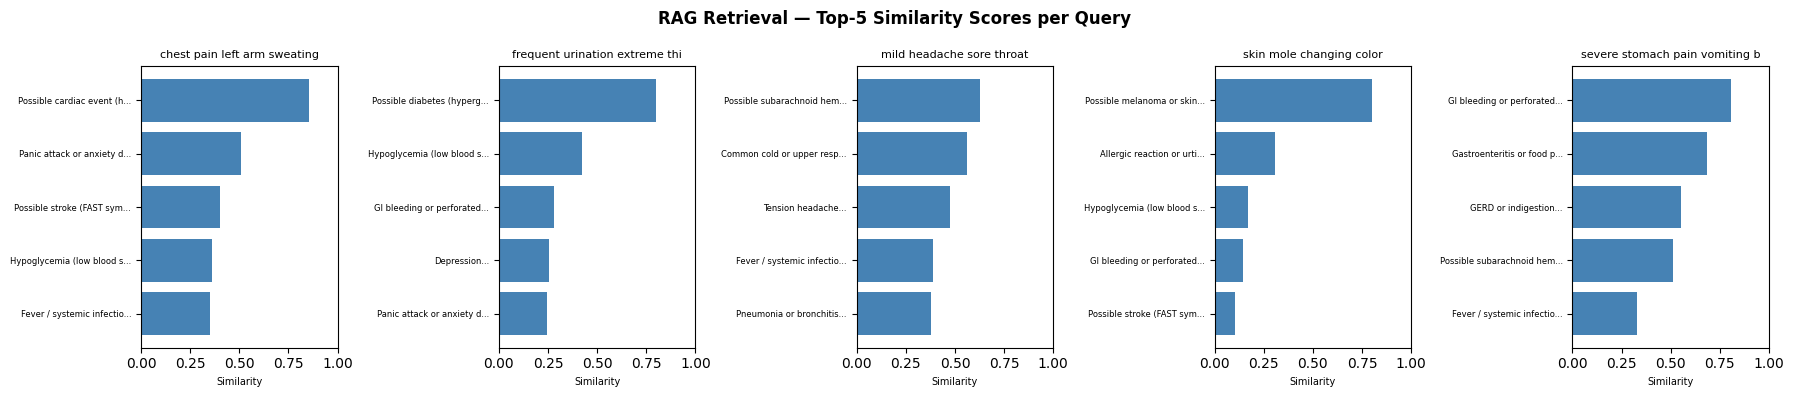

✅ RAG similarity chart saved!


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

queries = [
    "chest pain left arm sweating",
    "frequent urination extreme thirst",
    "mild headache sore throat",
    "skin mole changing color",
    "severe stomach pain vomiting blood"
]

fig, axes = plt.subplots(1, len(queries), figsize=(18, 4))
fig.suptitle('RAG Retrieval — Top-5 Similarity Scores per Query', fontsize=12, fontweight='bold')

for ax, query in zip(axes, queries):
    vec = embedder.encode([query], convert_to_numpy=True)
    vec = vec / np.linalg.norm(vec, axis=1, keepdims=True)
    scores, indices = index.search(vec.astype(np.float32), 5)
    labels = [KNOWLEDGE_BASE[i]['condition'][:25] + '...' for i in indices[0]]
    ax.barh(labels[::-1], scores[0][::-1], color='steelblue')
    ax.set_xlim(0, 1)
    ax.set_title(query[:30], fontsize=8)
    ax.set_xlabel('Similarity', fontsize=7)
    ax.tick_params(axis='y', labelsize=6)

plt.tight_layout()
plt.savefig('healthcare_ai/data/phase4_rag_similarity.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ RAG similarity chart saved!')

## Step 10: Verify DB Logs + Save Chatbot

In [19]:
# Verify symptom logs in DB
with sqlite3.connect(DB_PATH) as conn:
    logs = pd.read_sql(
        'SELECT patient_id, symptoms_text, severity, created_at FROM symptom_logs ORDER BY created_at DESC LIMIT 10',
        conn
    )
print('📋 Latest symptom logs in database:')
print(logs.to_string(index=False))

# Save embedder reference path
chatbot_config = {
    'embedder_model': 'all-MiniLM-L6-v2',
    'faiss_index_path': os.path.join(MODEL_DIR, 'medical_faiss.index'),
    'knowledge_base_path': os.path.join(MODEL_DIR, 'knowledge_base.pkl')
}
with open(os.path.join(MODEL_DIR, 'chatbot_config.pkl'), 'wb') as f:
    pickle.dump(chatbot_config, f)

print('\n💾 Chatbot config saved!')
print('\n✅ Phase 4 complete!')

📋 Latest symptom logs in database:
 patient_id                                                           symptoms_text  severity          created_at
          1                                     Hi there, I need some health advice       low 2026-06-02 16:17:51
          1              I've been having a fever of 101F and body aches for 2 days    medium 2026-06-02 16:17:51
          1                            I also have a cough and chest congestion now      high 2026-06-02 16:17:51
          1                                                                  Hello!       low 2026-06-02 16:17:35
          1          I have chest pain and my left arm feels numb since an hour ago emergency 2026-06-02 16:17:35
          2 I've been feeling extremely thirsty and urinating frequently for 3 days       low 2026-06-02 16:17:35
          3                    I have a mild headache and sore throat since morning emergency 2026-06-02 16:17:35
          4       I noticed a mole on my arm that has

---
## ✅ Phase 4 Complete!

**What you built:**
- 20-entry medical knowledge base covering 8 disease categories
- Sentence embeddings with `all-MiniLM-L6-v2`
- FAISS cosine-similarity vector store (RAG retrieval)
- Intent classifier (emergency / urgent / symptom / general / greeting)
- Severity triage engine with clinical action recommendations
- `MedicalChatbot` with conversation memory + DB logging
- RAG similarity visualization

**Next → Phase 5: FastAPI Backend**
- REST API wiring all 3 AI modules together
- Endpoints: `/predict-risk`, `/scan-image`, `/chat`
- Patient CRUD, authentication, response schemas
- Runnable directly from Jupyter with `uvicorn`